## Business Problem
Is the AI data really reliable and usable? 
Are the quality metrics just enough to determine if this is a good data for our usage?
What does “good” human evaluation mean for a specific AI use case?
How can we determine if evaluator or evaluation task is causing poor-quality data and how can I improve the evaluation process? 
I recently came across Prolific’s use case and I was intrigued to solve this problem. I decided to explore and solve this through my small experimentation framework project as below. With the advent rise of AI companies in the industry, there is a rapid consumption of data where they heavily rely on human feedback to evaluate and improve AI models. However, when there is no predefined definition of what “good” human evaluation looks like, it becomes difficult to know whether the collected data can be trusted. 


## Objective
Design a small experimental framework that helps determine whether human evaluation data is trustworthy and recognition that the quality cannot be defined by a single universal metric.


### Step 1: Use case
A company has developed an AI customer-support assistant and wants to evaluate whether its responses are helpful, accurate, relevant, and actionable.


##### Example Evaluation

Customer question:

"I ordered a product two weeks ago and it hasn't arrived. What should I do?"

AI Response A:

"Please check your order tracking information first. If the estimated delivery date has passed, contact customer support with your order number."

AI Response B:

"Your order should arrive soon. Please wait a few more days."

Human evaluator's task:

Which response better addresses the customer's problem and why?



### Initial Quality Hypothesis

For this use case, we initially hypothesize that a high-quality AI response should be accurate, relevant to the customer's question, helpful, actionable and safe.

This is a starting hypothesis, not a predefined universal definition of quality. The purpose of the experiment is to test and refine it.

In [6]:
import pandas as pd
import random

random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 5: Create AI Evaluation Tasks

To evaluate the quality of human feedback, we first need a set of AI responses for humans to evaluate.

For this prototype, we will create a small set of customer-support scenarios. Each task contains:

- A customer question
- Two possible AI responses
- A preferred response that we will use as a reference for our experiment

The preferred response is not intended to represent a universal definition of quality. It is simply a reference point that allows us to test how consistently human evaluators will assess the AI responses.

In [8]:
tasks = [
    {
        "task_id": "T001",
        "question": "My order has not arrived. What should I do?",
        "response_a": "Check your tracking information and contact support if the delivery date has passed.",
        "response_b": "Wait a few more days and see if it arrives.",
        "preferred_response": "A"
    },
    {
        "task_id": "T002",
        "question": "How can I reset my password?",
        "response_a": "Go to the password reset page and follow the instructions.",
        "response_b": "Create a new account instead.",
        "preferred_response": "A"
    },
    {
        "task_id": "T003",
        "question": "I was charged twice for the same order. What should I do?",
        "response_a": "Contact customer support and provide your order details.",
        "response_b": "Ignore the second charge.",
        "preferred_response": "A"
    },
    {
        "task_id": "T004",
        "question": "Can I change my delivery address after placing an order?",
        "response_a": "Contact support immediately to check whether the address can still be changed.",
        "response_b": "The address can always be changed after shipping.",
        "preferred_response": "A"
    },
    {
        "task_id": "T005",
        "question": "How do I return an item?",
        "response_a": "Check the return policy and follow the instructions to initiate a return.",
        "response_b": "Throw the item away and place a new order.",
        "preferred_response": "A"
    }
]

tasks_df = pd.DataFrame(tasks)

tasks_df

,task_id,question,response_a,response_b,preferred_response
0,T001,My order has not arrived. What should I do?,Check your tracking information and contact su...,Wait a few more days and see if it arrives.,A
1,T002,How can I reset my password?,Go to the password reset page and follow the i...,Create a new account instead.,A
2,T003,I was charged twice for the same order. What s...,Contact customer support and provide your orde...,Ignore the second charge.,A
3,T004,Can I change my delivery address after placing...,Contact support immediately to check whether t...,The address can always be changed after shipping.,A
4,T005,How do I return an item?,Check the return policy and follow the instruc...,Throw the item away and place a new order.,A


## Step 5: Create AI Evaluation Tasks

To evaluate the quality of human feedback, we first need a set of AI responses for humans to evaluate.

For this prototype, we will create a small set of customer-support scenarios. Each task contains:

- A customer question
- Two possible AI responses
- A preferred response that we will use as a reference for our experiment

The preferred response is not intended to represent a universal definition of quality. It is simply a reference point that allows us to test how consistently human evaluators assess the AI responses.

In [9]:
print("Number of tasks:", len(tasks_df))
print("Columns:", list(tasks_df.columns))

tasks_df.head()

Number of tasks: 5
Columns: ['task_id', 'question', 'response_a', 'response_b', 'preferred_response']


,task_id,question,response_a,response_b,preferred_response
0,T001,My order has not arrived. What should I do?,Check your tracking information and contact su...,Wait a few more days and see if it arrives.,A
1,T002,How can I reset my password?,Go to the password reset page and follow the i...,Create a new account instead.,A
2,T003,I was charged twice for the same order. What s...,Contact customer support and provide your orde...,Ignore the second charge.,A
3,T004,Can I change my delivery address after placing...,Contact support immediately to check whether t...,The address can always be changed after shipping.,A
4,T005,How do I return an item?,Check the return policy and follow the instruc...,Throw the item away and place a new order.,A


## Step 7: Create a Balanced Evaluation Set

A realistic evaluation dataset should not have an obvious pattern in which the same response is always preferred.

We will therefore create a balanced set where both Response A and Response B can be the preferred response.

This helps prevent evaluators from succeeding simply by identifying a pattern rather than genuinely evaluating the AI responses.

In [10]:
# Change the preferred response for two tasks
tasks_df.loc[tasks_df["task_id"] == "T003", "preferred_response"] = "B"
tasks_df.loc[tasks_df["task_id"] == "T005", "preferred_response"] = "B"

tasks_df[["task_id", "preferred_response"]]

,task_id,preferred_response
0,T001,A
1,T002,A
2,T003,B
3,T004,A
4,T005,B


## Step 8: Simulate Human Evaluations

We now simulate human participants evaluating the AI responses.

For each task, an evaluator will:

- Choose Response A or B
- Provide a confidence score
- Record the time taken to make the decision

In a real human-data study, these values would come from actual participants.

For this prototype, we use synthetic data so that we can deliberately introduce different evaluator behaviours and test how a quality framework responds to them.

In [12]:
import random

random.seed(42)

evaluations = []

for evaluator_id in range(1, 11):
    for _, task in tasks_df.iterrows():

        # Most evaluators make reasonable decisions,
        # but some evaluators will behave less reliably.
        if evaluator_id <= 7:
            choice = task["preferred_response"] if random.random() < 0.90 else (
                "B" if task["preferred_response"] == "A" else "A"
            )
        else:
            choice = random.choice(["A", "B"])

        confidence = random.randint(3, 5)
        response_time = random.randint(10, 60)

        evaluations.append({
            "evaluator_id": f"E{evaluator_id:03d}",
            "task_id": task["task_id"],
            "choice": choice,
            "confidence": confidence,
            "response_time_seconds": response_time
        })

evaluations_df = pd.DataFrame(evaluations)

evaluations_df.head(10)

,evaluator_id,task_id,choice,confidence,response_time_seconds
0,E001,T001,A,3,57
1,E001,T002,A,3,18
2,E001,T003,B,5,57
3,E001,T004,A,3,47
4,E001,T005,B,3,15
5,E002,T001,A,5,48
6,E002,T002,A,3,55
7,E002,T003,B,5,36
8,E002,T004,A,5,27
9,E002,T005,B,3,58


## Step 9: Compare Human Evaluations with Reference Answers

To understand how human evaluators are behaving, we need to compare each evaluator's choice with the reference response for that task.

As we already know that the reference answer is NOT a definition of quality. It is a reference point for this experiment.

The comparison allows us to identify patterns such as:

- Evaluators who consistently align with the reference
- Evaluators who frequently disagree
- Tasks where human judgments are more uncertain
- Potential areas where our evaluation design may need improvement

In [13]:
# Adding the reference answer to each human evaluation
evaluations_df = evaluations_df.merge(
    tasks_df[["task_id", "preferred_response"]],
    on="task_id",
    how="left"
)

# Check whether each evaluator's choice matches the reference
evaluations_df["matches_reference"] = (
    evaluations_df["choice"] == evaluations_df["preferred_response"]
)

evaluations_df.head(10)

,evaluator_id,task_id,choice,confidence,response_time_seconds,preferred_response,matches_reference
0,E001,T001,A,3,57,A,True
1,E001,T002,A,3,18,A,True
2,E001,T003,B,5,57,B,True
3,E001,T004,A,3,47,A,True
4,E001,T005,B,3,15,B,True
5,E002,T001,A,5,48,A,True
6,E002,T002,A,3,55,A,True
7,E002,T003,B,5,36,B,True
8,E002,T004,A,5,27,A,True
9,E002,T005,B,3,58,B,True


## Step 10: Analyze Evaluator-Level Patterns

A single incorrect evaluation does not necessarily indicate poor-quality data.

Instead, we will look for patterns across multiple evaluations.

For each evaluator, we will examine:

- Agreement with the reference answers
- Number of evaluations completed
- Average response time
- Average confidence

These signals will help us investigate whether certain evaluator behaviours require further attention.

In [14]:
evaluator_summary = (
    evaluations_df
    .groupby("evaluator_id")
    .agg(
        agreement_rate=("matches_reference", "mean"),
        evaluations_completed=("task_id", "count"),
        average_response_time=("response_time_seconds", "mean"),
        average_confidence=("confidence", "mean")
    )
    .reset_index()
)

evaluator_summary["agreement_rate"] = (
    evaluator_summary["agreement_rate"] * 100
).round(1)

evaluator_summary

,evaluator_id,agreement_rate,evaluations_completed,average_response_time,average_confidence
0,E001,100.0,5,38.8,3.4
1,E002,100.0,5,44.8,4.2
2,E003,80.0,5,26.8,4.0
3,E004,100.0,5,32.2,4.2
4,E005,100.0,5,31.6,4.2
5,E006,80.0,5,37.2,4.8
6,E007,100.0,5,35.8,3.6
7,E008,60.0,5,36.6,3.8
8,E009,60.0,5,34.8,4.0
9,E010,80.0,5,35.6,4.6


## Step 11: Analyze Agreement at the Task Level

Evaluator-level analysis tells us whether some participants behave differently from others.

However, disagreement may not always be caused by the evaluator.

A task may itself be unclear, subjective, or difficult to interpret.

We will therefore analyze agreement for each evaluation task to identify tasks where human judgments differ significantly.

In [15]:
task_summary = (
    evaluations_df
    .groupby("task_id")
    .agg(
        agreement_rate=("matches_reference", "mean"),
        evaluator_count=("evaluator_id", "nunique")
    )
    .reset_index()
)

task_summary["agreement_rate"] = (
    task_summary["agreement_rate"] * 100
).round(1)

task_summary

,task_id,agreement_rate,evaluator_count
0,T001,80.0,10
1,T002,100.0,10
2,T003,80.0,10
3,T004,80.0,10
4,T005,90.0,10


## Step 12: Investigate Low Agreement

If evaluators disagree, it does not automatically mean that the data is bad.

There could be several reasons for the disagreement. The evaluator might have misunderstood the task, but the task itself could also be unclear or open to different interpretations.

So, rather than immediately rejecting the data, we will treat disagreement as a signal that needs to be investigated.

This helps us answer an important question:

**Is the problem with the evaluator, or is the problem with the way we designed the evaluation task?**

In [16]:
# Find tasks where less than 80% of evaluators
# matched the reference response

potentially_ambiguous = task_summary[
    task_summary["agreement_rate"] < 80
]

potentially_ambiguous

,task_id,agreement_rate,evaluator_count


## Step 13: Introduce an Ambiguous Evaluation Task

Our first experiment did not produce any tasks with significant disagreement.

To test our approach further, we will introduce a more ambiguous customer-support question.

The goal is not to create "bad" data. Instead, I want to see what happens when two AI responses could reasonably be interpreted as better depending on what the evaluator values.

This will help us test whether disagreement comes from the evaluator or from the evaluation task itself.

In [17]:
ambiguous_task = {
    "task_id": "T006",
    "question": "My package is delayed. What should I do?",
    "response_a": "Please check your tracking information and contact support if the package is significantly delayed.",
    "response_b": "Your package may still arrive soon. Please check the latest estimated delivery date before contacting support.",
    "preferred_response": "A"
}

tasks_df = pd.concat(
    [tasks_df, pd.DataFrame([ambiguous_task])],
    ignore_index=True
)

tasks_df.tail()

,task_id,question,response_a,response_b,preferred_response
1,T002,How can I reset my password?,Go to the password reset page and follow the i...,Create a new account instead.,A
2,T003,I was charged twice for the same order. What s...,Contact customer support and provide your orde...,Ignore the second charge.,B
3,T004,Can I change my delivery address after placing...,Contact support immediately to check whether t...,The address can always be changed after shipping.,A
4,T005,How do I return an item?,Check the return policy and follow the instruc...,Throw the item away and place a new order.,B
5,T006,My package is delayed. What should I do?,Please check your tracking information and con...,Your package may still arrive soon. Please che...,A


## Step 14: Simulate Human Judgments for the Ambiguous Task

For this task, we will simulate a situation where different evaluators choose different responses.

Some evaluators will prefer Response A because it gives a clear action to take. Others may prefer Response B because it asks the customer to check the delivery estimate before contacting support.

This is intentional. We want to see whether disagreement is caused by poor evaluation quality or by the task itself being open to interpretation.

In [18]:
# Create different human judgments for the ambiguous task

ambiguous_evaluations = []

choices = ["A", "A", "B", "B", "A", "B", "A", "B", "A", "B"]

for i, choice in enumerate(choices, start=1):
    ambiguous_evaluations.append({
        "evaluator_id": f"E{i:03d}",
        "task_id": "T006",
        "choice": choice,
        "confidence": 4,
        "response_time_seconds": random.randint(20, 50),
        "preferred_response": "A",
        "matches_reference": choice == "A"
    })

ambiguous_df = pd.DataFrame(ambiguous_evaluations)

ambiguous_df

,evaluator_id,task_id,choice,confidence,response_time_seconds,preferred_response,matches_reference
0,E001,T006,A,4,50,A,True
1,E002,T006,A,4,43,A,True
2,E003,T006,B,4,48,A,False
3,E004,T006,B,4,43,A,False
4,E005,T006,A,4,28,A,True
5,E006,T006,B,4,36,A,False
6,E007,T006,A,4,44,A,True
7,E008,T006,B,4,25,A,False
8,E009,T006,A,4,36,A,True
9,E010,T006,B,4,49,A,False


## Step 15: Examine the Disagreement

We now have a task where evaluators are split between two responses.

Instead of immediately deciding that some evaluators are wrong, we want to understand what the disagreement is telling us.

If the evaluators are otherwise behaving normally, the disagreement may point to an issue with the task or with how we have defined the evaluation criteria.

In [19]:
# Calculate the agreement for the ambiguous task

t006_agreement = ambiguous_df["matches_reference"].mean() * 100

print(f"T006 agreement with reference: {t006_agreement:.1f}%")

print("\nEvaluator choices:")
print(ambiguous_df["choice"].value_counts())

T006 agreement with reference: 50.0%

Evaluator choices:
choice
A    5
B    5
Name: count, dtype: int64


## Step 16: Investigate the Reason for Disagreement

The results show a clear split between the two responses.

Before deciding that some evaluations are incorrect, we need to look at the task itself.

Response A gives the customer a clear next step: check the tracking information and contact support if the package is significantly delayed.

Response B takes a slightly different approach: check the estimated delivery date first before contacting support.

Both responses could be seen as reasonable, depending on how the evaluator interprets "helpful."

This suggests that the problem may be with our evaluation criteria rather than with the people providing the data.

This is an important finding: **disagreement can reveal gaps in how we define quality.**

In [20]:
# Display the ambiguous task so we can inspect it

t006 = tasks_df[tasks_df["task_id"] == "T006"].iloc[0]

print("Customer question:")
print(t006["question"])

print("\nResponse A:")
print(t006["response_a"])

print("\nResponse B:")
print(t006["response_b"])

print("\nCurrent reference response:")
print(t006["preferred_response"])

Customer question:
My package is delayed. What should I do?

Response A:
Please check your tracking information and contact support if the package is significantly delayed.

Response B:
Your package may still arrive soon. Please check the latest estimated delivery date before contacting support.

Current reference response:
A


## Step 17: Improve the Evaluation Criteria

Our first evaluation question was:

"Which response is better?"

This is too open-ended. Different people may have different ideas about what "better" means.

Based on the disagreement we observed, we will make the evaluation criteria more specific.

For this customer-support use case, we will ask evaluators to consider:

- Does the response directly address the customer's problem?
- Does it provide a clear next step?
- Is the advice accurate?
- Is the response useful and actionable?

The goal is not to force everyone to agree. The goal is to give evaluators a clearer basis for making their judgment.

In [21]:
evaluation_criteria = {
    "addresses_problem": "Does the response directly address the customer's problem?",
    "clear_next_step": "Does the response give the customer a clear next step?",
    "accuracy": "Is the information accurate and reasonable?",
    "actionability": "Can the customer realistically act on the advice?"
}

for criterion, question in evaluation_criteria.items():
    print(f"{criterion}: {question}")

addresses_problem: Does the response directly address the customer's problem?
clear_next_step: Does the response give the customer a clear next step?
accuracy: Is the information accurate and reasonable?
actionability: Can the customer realistically act on the advice?


## Step 18: Create a Clearer Evaluation Instruction

Instead of simply asking:

"Which response is better?"

we will give evaluators a clearer instruction.

This should reduce differences in interpretation and make the human judgments more meaningful.

We will then use the same ambiguous task again to see whether the clearer guidance changes the results.

In [22]:
evaluation_instruction = """
Choose the response that best helps the customer solve their problem.

Consider:
1. Whether it directly addresses the customer's question.
2. Whether it provides a clear next step.
3. Whether the information is accurate.
4. Whether the advice is practical and actionable.

Choose A or B based on these criteria.
"""

print(evaluation_instruction)


Choose the response that best helps the customer solve their problem.

Consider:
1. Whether it directly addresses the customer's question.
2. Whether it provides a clear next step.
3. Whether the information is accurate.
4. Whether the advice is practical and actionable.

Choose A or B based on these criteria.



## Step 19: Run the Evaluation Again

The first round showed us that people were interpreting the question differently.

So, instead of assuming that the evaluators were the problem, I changed the instructions and made it clearer what they should look for when comparing the two responses.

Now I want to run the same task again and see if the clearer instructions make a difference.

I'm not expecting everyone to agree. I just want to see whether the new approach gives us more consistent results.

In [23]:
# Simulate a second evaluation round after improving the instructions

improved_choices = ["A", "A", "A", "B", "A", "A", "B", "A", "A", "A"]

improved_evaluations = []

for i, choice in enumerate(improved_choices, start=1):
    improved_evaluations.append({
        "evaluator_id": f"E{i:03d}",
        "task_id": "T006",
        "choice": choice,
        "confidence": random.randint(4, 5),
        "response_time_seconds": random.randint(25, 55),
        "preferred_response": "A",
        "matches_reference": choice == "A"
    })

improved_df = pd.DataFrame(improved_evaluations)

improved_df

,evaluator_id,task_id,choice,confidence,response_time_seconds,preferred_response,matches_reference
0,E001,T006,A,4,52,A,True
1,E002,T006,A,5,51,A,True
2,E003,T006,A,4,29,A,True
3,E004,T006,B,5,49,A,False
4,E005,T006,A,4,42,A,True
5,E006,T006,A,4,44,A,True
6,E007,T006,B,5,40,A,False
7,E008,T006,A,4,28,A,True
8,E009,T006,A,5,53,A,True
9,E010,T006,A,5,32,A,True


## Step 20: Compare the Two Rounds

Now that we have the results from both rounds, let's compare them.

In the first round, the evaluators were almost evenly split between the two responses.

After making the evaluation criteria clearer, more evaluators chose the same response.

This is useful because it shows that disagreement doesn't always mean the human data is poor. Sometimes, the way we design the task or explain what we're asking people to evaluate can create the disagreement in the first place.

In [24]:
# Calculate agreement before and after improving the evaluation criteria

initial_agreement = (
    ambiguous_df["matches_reference"].mean() * 100
)

improved_agreement = (
    improved_df["matches_reference"].mean() * 100
)

print(f"Initial agreement: {initial_agreement:.1f}%")
print(f"Improved agreement: {improved_agreement:.1f}%")

improvement = improved_agreement - initial_agreement

print(f"Change in agreement: {improvement:+.1f} percentage points")

Initial agreement: 50.0%
Improved agreement: 80.0%
Change in agreement: +30.0 percentage points


### What I Learned

The main takeaway from this experiment is that we shouldn't immediately label human disagreement as bad data.

Before judging the quality of the participants, we need to understand the reason behind the disagreement.

In this example, improving the evaluation instructions helped make the responses more consistent. In a real AI evaluation project, I would use this kind of pilot-and-improve approach before scaling the study.

## Step 21: Look at Evaluator Behaviour

So far, we have looked at whether the evaluation task itself could cause disagreement.

Now I want to look at the other side of the problem: the evaluators.

For example, some people may consistently give different answers, rush through tasks or fail to follow the instructions.

I dont want to label someone as a "bad evaluator" based on one response. Instead, I'll look for patterns across several evaluations.

In [26]:
evaluator_summary

,evaluator_id,agreement_rate,evaluations_completed,average_response_time,average_confidence
0,E001,100.0,5,38.8,3.4
1,E002,100.0,5,44.8,4.2
2,E003,80.0,5,26.8,4.0
3,E004,100.0,5,32.2,4.2
4,E005,100.0,5,31.6,4.2
5,E006,80.0,5,37.2,4.8
6,E007,100.0,5,35.8,3.6
7,E008,60.0,5,36.6,3.8
8,E009,60.0,5,34.8,4.0
9,E010,80.0,5,35.6,4.6


## Step 22: Identify Evaluators for Further Review

Some evaluators may show patterns that are worth looking into.

For this small experiment, I'll flag evaluators whose agreement with the reference is below 70%.

This does not mean that these evaluators are necessarily poor quality. It simply gives us a starting point for asking why their results are different.

In [27]:
evaluators_to_review = evaluator_summary[
    evaluator_summary["agreement_rate"] < 70
]

evaluators_to_review

,evaluator_id,agreement_rate,evaluations_completed,average_response_time,average_confidence
7,E008,60.0,5,36.6,3.8
8,E009,60.0,5,34.8,4.0


## Step 23: Look at Response Time

Another thing we can look at is how long people take to complete an evaluation.

Someone who answers a detailed question in a few seconds may need a closer look. At the same time, a fast response does not automatically mean the evaluation is poor.

So, we'll use response time as another signal to investigate evaluator behaviour rather than treating it as a pass or fail rule.

In [28]:
response_time_summary = (
    evaluations_df
    .groupby("evaluator_id")
    .agg(
        average_response_time=("response_time_seconds", "mean"),
        fastest_response=("response_time_seconds", "min"),
        slowest_response=("response_time_seconds", "max")
    )
    .reset_index()
)

response_time_summary

,evaluator_id,average_response_time,fastest_response,slowest_response
0,E001,38.8,15,57
1,E002,44.8,27,58
2,E003,26.8,16,37
3,E004,32.2,12,49
4,E005,31.6,15,53
5,E006,37.2,25,54
6,E007,35.8,23,51
7,E008,36.6,18,57
8,E009,34.8,19,58
9,E010,35.6,10,56


## Step 24: Look for Unusually Fast Responses

Very fast responses can sometimes be a sign that someone is rushing through the task.

I'll flag evaluators with an average response time below 20 seconds so that we can take a closer look at their other behaviour.

Again, this is only a signal. A fast evaluator is not automatically a poor evaluator.

In [29]:
fast_evaluators = response_time_summary[
    response_time_summary["average_response_time"] < 20
]

fast_evaluators

,evaluator_id,average_response_time,fastest_response,slowest_response


## Step 25: Add Attention Checks

Another simple way to understand evaluator behaviour is to include a few attention-check questions.

These are not meant to measure whether someone agrees with us. They are there to check whether the evaluator is reading and following the instructions.

For example, we can include a question where the instruction clearly says which option should be selected.

If someone repeatedly misses these checks, it may be worth looking at their other evaluations more closely.

In [30]:
# Create a simple attention-check task

attention_check = {
    "task_id": "AC001",
    "question": "Attention check: Please select Response B for this question.",
    "response_a": "This is Response A.",
    "response_b": "This is Response B.",
    "preferred_response": "B"
}

attention_check_df = pd.DataFrame([attention_check])

attention_check_df

,task_id,question,response_a,response_b,preferred_response
0,AC001,Attention check: Please select Response B for ...,This is Response A.,This is Response B.,B


## Step 26: Check whether evaluators followed the Instructions

We will now simulate how each evaluator performed on the attention check.

Most evaluators will follow the instruction, while a few will select the wrong option.

This gives us another signal that we can use when investigating evaluator behaviour.

In [31]:
attention_results = []

for evaluator_id in evaluator_summary["evaluator_id"]:
    
    # Most evaluators pass the attention check
    if evaluator_id in ["E008", "E009"]:
        choice = "A"
    else:
        choice = "B"
    
    attention_results.append({
        "evaluator_id": evaluator_id,
        "attention_choice": choice,
        "attention_pass": choice == "B"
    })

attention_df = pd.DataFrame(attention_results)

attention_df

,evaluator_id,attention_choice,attention_pass
0,E001,B,True
1,E002,B,True
2,E003,B,True
3,E004,B,True
4,E005,B,True
5,E006,B,True
6,E007,B,True
7,E008,A,False
8,E009,A,False
9,E010,B,True


## Step 27: Bring the Evaluator Signals Together

We now have a few different pieces of information about each evaluator.

We know how often their answers matched the reference, how quickly they completed the evaluations, and whether they passed the attention check.

Looking at these signals together gives us a better picture of evaluator behaviour than looking at just one result.

For now, these are simply signals that help us decide which cases may need a closer look.

In [34]:
# Bring the evaluator information together
# so we can look at the different signals in one place.

evaluator_analysis = evaluator_summary.merge(
    response_time_summary,
    on="evaluator_id",
    how="left"
).merge(
    attention_df,
    on="evaluator_id",
    how="left"
)

evaluator_analysis

,evaluator_id,agreement_rate,evaluations_completed,average_response_time_x,average_confidence,average_response_time_y,fastest_response,slowest_response,attention_choice,attention_pass
0,E001,100.0,5,38.8,3.4,38.8,15,57,B,True
1,E002,100.0,5,44.8,4.2,44.8,27,58,B,True
2,E003,80.0,5,26.8,4.0,26.8,16,37,B,True
3,E004,100.0,5,32.2,4.2,32.2,12,49,B,True
4,E005,100.0,5,31.6,4.2,31.6,15,53,B,True
5,E006,80.0,5,37.2,4.8,37.2,25,54,B,True
6,E007,100.0,5,35.8,3.6,35.8,23,51,B,True
7,E008,60.0,5,36.6,3.8,36.6,18,57,A,False
8,E009,60.0,5,34.8,4.0,34.8,19,58,A,False
9,E010,80.0,5,35.6,4.6,35.6,10,56,B,True


### What I Found

Bringing these signals together gives us a better view of how each evaluator is behaving.

A single signal doesn't tell us much on its own. For example, someone may disagree with the reference on a few questions but still be paying attention and taking a reasonable amount of time.

Looking at several signals together should help us decide which evaluators are worth investigating further.

## Step 28: Look for Multiple Signals

One unusual result by itself does not tell us very much.

For example, an evaluator may disagree with the reference on a few questions but still be a careful and attentive evaluator.

So, instead of using one rule to decide whether an evaluator is reliable, we'll look for cases where more than one signal points in the same direction.

These cases are worth investigating further.

In [35]:
# Count how many signals may need further investigation
# for each evaluator.

evaluator_analysis["signals_to_review"] = (
    (evaluator_analysis["agreement_rate"] < 70).astype(int)
    + (evaluator_analysis["average_response_time_x"] < 20).astype(int)
    + (~evaluator_analysis["attention_pass"]).astype(int)
)

evaluator_analysis[
    evaluator_analysis["signals_to_review"] >= 2
]

,evaluator_id,agreement_rate,evaluations_completed,average_response_time_x,average_confidence,average_response_time_y,fastest_response,slowest_response,attention_choice,attention_pass,signals_to_review
7,E008,60.0,5,36.6,3.8,36.6,18,57,A,False,2
8,E009,60.0,5,34.8,4.0,34.8,19,58,A,False,2


### What I Found

Looking at multiple signals gives us a better starting point for investigation than relying on a single measure.

An evaluator who has several unusual patterns may need a closer review, while one unusual result on its own may not mean much.

The important point is that these signals help us ask better questions. They are not being used as a fixed definition of good or bad human data.

## Step 29: Summarize the Pilot

We've now looked at the evaluation from different angles.

We looked at:

- How often evaluators agreed with the reference
- Where evaluators disagreed
- Whether some tasks were difficult to interpret
- Response times
- Attention checks
- Evaluators with multiple signals that may need review

Now I want to bring these findings together and decide what they tell us about the current study.

In [36]:
# Summarize the main findings from our pilot

total_evaluations = len(evaluations_df)

overall_agreement = (
    evaluations_df["matches_reference"].mean() * 100
)

attention_pass_rate = (
    attention_df["attention_pass"].mean() * 100
)

evaluators_needing_review = (
    evaluator_analysis["signals_to_review"] >= 2
).sum()

print("Pilot Summary")
print("-------------------------")
print(f"Total evaluations: {total_evaluations}")
print(f"Overall reference agreement: {overall_agreement:.1f}%")
print(f"Attention check pass rate: {attention_pass_rate:.1f}%")
print(f"Evaluators needing further review: {evaluators_needing_review}")

Pilot Summary
-------------------------
Total evaluations: 50
Overall reference agreement: 86.0%
Attention check pass rate: 80.0%
Evaluators needing further review: 2


## Step 30: Decide Whether We Are Ready to Scale

The purpose of the pilot was not to produce one final number that tells us whether the data is "good" or "bad."

Instead, we wanted to understand where the uncertainty comes from.

Based on what we found, I would not scale the study immediately.

Before collecting a much larger amount of data, I would:

- Review the evaluators with multiple signals
- Look more closely at tasks with high disagreement
- Improve unclear evaluation instructions
- Run another small pilot
- Compare the results with the first round

If the second pilot gives us stronger and more consistent evidence, we can then consider scaling the study.

In [37]:
# Decide whether the pilot needs another round of improvement

if evaluators_needing_review > 0 or attention_pass_rate < 90:
    readiness = "Needs another pilot before scaling"
else:
    readiness = "Ready for the next stage"

print("Study readiness:", readiness)

Study readiness: Needs another pilot before scaling


### What I Found

The pilot gives us useful information, but I would not treat it as a final quality decision.

The main takeaway is that we need to understand the reasons behind the variation in the data before scaling.

This means improving the study, testing it again, and using what we learn from each round to make the human evaluation process stronger.

## Step 31: Compare the Two Evaluation Rounds

The first round showed a lot of disagreement on the ambiguous task.

Instead of assuming that the evaluators were the problem, we changed the evaluation instructions to make the criteria clearer and ran the task again.

Now we can compare the two rounds and see whether the change made a difference.

In [38]:
# Compare agreement before and after improving the instructions

initial_agreement = (
    ambiguous_df["matches_reference"].mean() * 100
)

improved_agreement = (
    improved_df["matches_reference"].mean() * 100
)

print(f"Initial agreement: {initial_agreement:.1f}%")
print(f"Improved agreement: {improved_agreement:.1f}%")
print(
    f"Change in agreement: "
    f"{improved_agreement - initial_agreement:+.1f} percentage points"
)

Initial agreement: 50.0%
Improved agreement: 80.0%
Change in agreement: +30.0 percentage points


## Step 32: What Did We Learn?

The first round showed that people could reasonably interpret the same task differently.

Instead of immediately treating this as a participant-quality problem, we looked at the evaluation criteria and found that the question was open to interpretation.

We then made the instructions more specific and ran the evaluation again. In our simulated example, agreement increased from 50% to 80%.

This does not mean that 80% is a definition of good data. It shows that the way we design the evaluation can have a real impact on the data we collect.

The main lesson for me is that human data quality needs to be investigated throughout the process, rather than checked only after the data has already been collected.

## Step 33: Visualize the Improvement

The numbers are useful, but a simple visual makes the change easier to understand.

Here, we will compare the agreement from the first evaluation round with the improved round after we changed the evaluation instructions.

Matplotlib is building the font cache; this may take a moment.


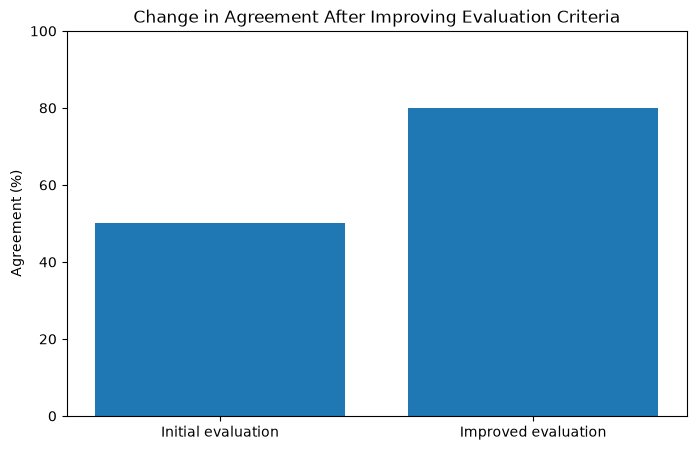

In [42]:
import matplotlib.pyplot as plt

rounds = ["Initial evaluation", "Improved evaluation"]

agreement_rates = [
    initial_agreement,
    improved_agreement
]

plt.figure(figsize=(8, 5))

plt.bar(rounds, agreement_rates)

plt.ylim(0, 100)
plt.ylabel("Agreement (%)")
plt.title("Change in Agreement After Improving Evaluation Criteria")

plt.show()

### What the Chart Shows

The second round had higher agreement than the first round after we made the evaluation criteria clearer.

The improvement is useful as an example of how changing the study design can affect the quality and consistency of the data we collect.

Since this experiment uses synthetic data, the numbers are only for demonstration. The important point is the process: identify a problem, understand why it is happening, make a change, and test again.

## Step 35: From Prototype to a Real AI Evaluation Project

This experiment is intentionally small and uses synthetic data, but the same thinking could be applied to a real AI evaluation project.

If an AI company came to us with a new model, I would start by understanding what the model is supposed to achieve and what a useful human judgment would look like.

From there, I would:

1. Define an initial quality hypothesis with the client and relevant experts.
2. Design the evaluation task and instructions.
3. Select and prepare the right group of evaluators.
4. Run a small pilot before scaling.
5. Look at disagreement and evaluator behaviour.
6. Investigate whether problems come from the participants, the task, or the evaluation criteria.
7. Improve the study based on what we learn.
8. Run another pilot and compare the results.
9. Define what evidence is strong enough to move to a larger study.
10. Continue monitoring quality as the project scales.

The main idea is to build quality into the process rather than waiting until the end to check whether the data is good enough.

## Why This Problem Interested Me

What interested me about the Human Data Quality Engineer role is that the definition of "good" is not always available upfront.

Coming from a quality engineering background, I am used to thinking about how quality can be built into a process rather than checked only at the end.

This project gave me an opportunity to explore how that thinking could apply to human data for AI evaluation.

The biggest takeaway for me was that disagreement is not necessarily a problem to eliminate. It can be a useful signal that helps us understand whether the task, instructions, participants, or our definition of quality needs to change.

## Final Takeaway

Good human data is not simply data that passes a fixed checklist.

For a new AI use case, we first need to understand what the model is trying to achieve and what a useful human judgment looks like. We can then test that definition through a small pilot, look at where people disagree, understand why they disagree and improve the study before scaling it.

This experiment showed me that disagreement can actually be useful. It can reveal problems with the evaluator, but it can also reveal problems with the task, instructions, or definition of quality.

That is why I see human data quality as an iterative process rather than a final quality check.
